In [7]:
import pandas as pd  # Setup and Load Data
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
# Convert smoker to numeric
df['smoker_numeric'] = df['smoker'].map({'yes': 1, 'no': 0})

# Select features (X) and target (y)
X = df[['age', 'bmi', 'smoker_numeric']]
y = df['charges']


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions and evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print(f"Model trained! The average prediction error (MAE) is: ${mae:.2f}")


Model trained! The average prediction error (MAE) is: $4260.56


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


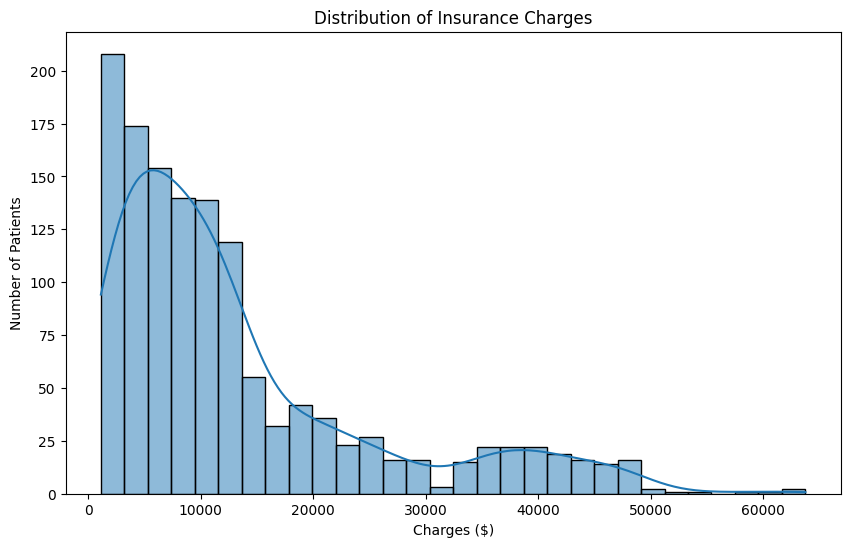

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, bins=30)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Number of Patients')
plt.show()


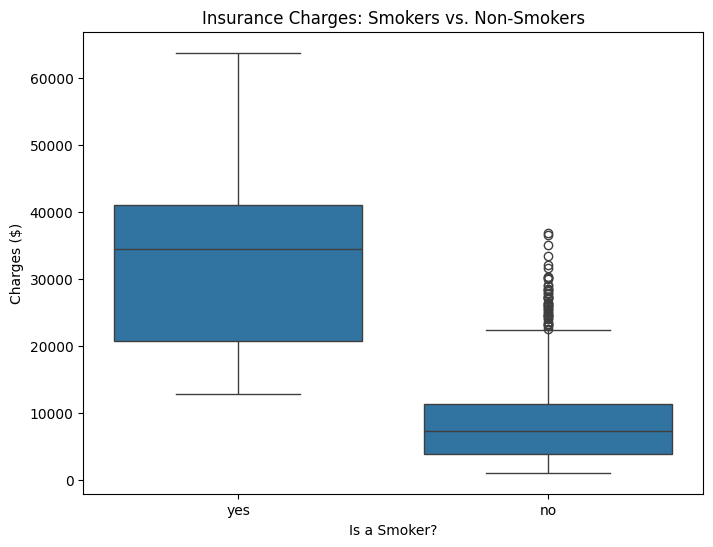

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges: Smokers vs. Non-Smokers')
plt.xlabel('Is a Smoker?')
plt.ylabel('Charges ($)')
plt.show()


In [20]:
print("─── BUILDING A SMARTER MODEL ───")

# 1. Convert categorical variables into numbers using One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['sex', 'region'], drop_first=True)

# Let's see our new DataFrame with the new columns
print("DataFrame with new encoded features:")
print(df_encoded.head())

# 2. Define our NEW list of features, including the new ones
new_features = ['age', 'bmi', 'smoker_numeric', 'sex_male',
                'region_northwest', 'region_southeast', 'region_southwest']

X_new = df_encoded[new_features]
y_new = df_encoded['charges']   # The target is the same

# 3. Create a new train-test split with the enhanced data
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# 4. Create and train a NEW Linear Regression model
smarter_model = LinearRegression()
smarter_model.fit(X_train_new, y_train_new)

# 5. Make predictions and evaluate the new model
new_predictions = smarter_model.predict(X_test_new)
new_mae = mean_absolute_error(y_test_new, new_predictions)

print(f"\nBaseline Model Error (MAE): ${mae:.2f}")
print(f"Smarter Model Error (MAE) with more features: ${new_mae:.2f}")

improvement = mae - new_mae
print(f"Improvement: ${improvement:.2f}")

if improvement > 0:
    print("\nConclusion: Success! By adding more features, we built a more accurate model.")
else:
    print("\nConclusion: Interesting! The new features didn’t help much. This is also a valid finding.")


─── BUILDING A SMARTER MODEL ───
DataFrame with new encoded features:
   age     bmi  children smoker      charges   smoker numeric  smoker_numeric  \
0   19  27.900         0    yes  16884.92400                1               1   
1   18  33.770         1     no   1725.55230                0               0   
2   28  33.000         3     no   4449.46200                0               0   
3   33  22.705         0     no  21984.47061                0               0   
4   32  28.880         0     no   3866.85520                0               0   

   sex_male  region_northwest  region_southeast  region_southwest  
0     False             False             False              True  
1      True             False              True             False  
2      True             False              True             False  
3      True              True             False             False  
4      True              True             False             False  

Baseline Model Error (MAE): $4260.

ValueError: x and y must have same first dimension, but have shapes (20,) and (0,)

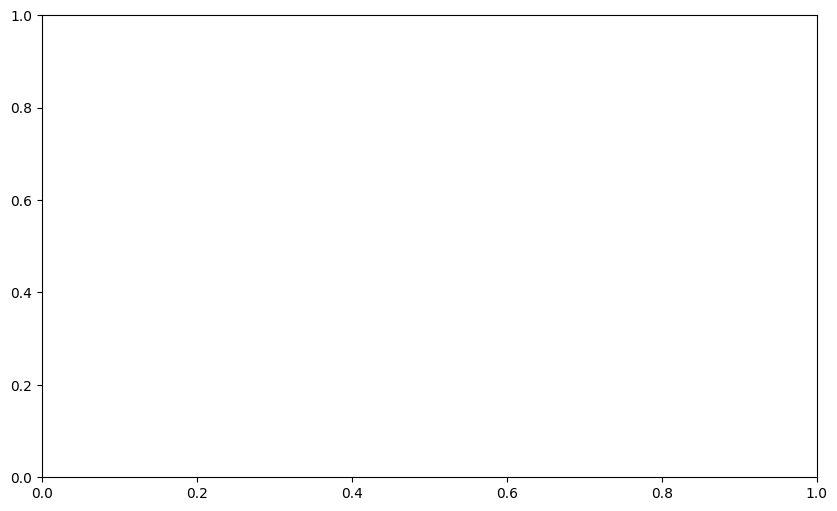

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(k_values, accuracies, marker='o', linestyle='--')
plt.title('KNN Accuracy for Different Values of K')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy on Test Set')
plt.xticks(k_values)
plt.grid(True)
plt.show()


In [33]:
!git --version


git version 2.34.1


In [38]:
!git clone https://github.com/uthpalahettiarachchi/type-ai--in-healthcare-portfolio

fatal: destination path 'type-ai--in-healthcare-portfolio' already exists and is not an empty directory.


In [35]:

!git commit -m "Train and Test the Linear Regression Model"
!git push origin main


fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
